# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_3_PCA

- 입력 데이터: 02_EDA가 저장한 `labeled_modeling.csv`
- 이 노트북의 역할: 차원축소(PCA) 검토 (스크리닝)
- 평가 프로토콜: 80/20 단일 분할 (`random_state=0`), test set 1046건 / 불량 12건
- 주의: 여기 수치는 **후보 비교용**임. 보고 수치는 **04_6 반복 CV 기준** (`ANALYSIS_FLOW.md` 참고)

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
# 02_EDA에서 저장한 전처리 데이터
# - 기록 오류 보정, 중복 제거, CN7·RG3 한정, PassOrFail 인코딩(양품 0 / 불량 1), Part 파생까지 끝난 상태
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

print(f'{model_data.shape[0]}행 {model_data.shape[1]}컬럼 / 불량 {int(model_data["PassOrFail"].sum())}건')

result_df=pd.read_csv('04_2_GridSearchCV.csv')

5230행 30컬럼 / 불량 60건


In [4]:
model_data.head()

,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Part
0,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.47,16.92,59.520000,...,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5,CN7RH
1,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7RH
2,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7LH
3,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7LH
4,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7RH


In [5]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


## PCA 실험

In [6]:
# PCA 실험 공통 라이브러리
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 공통 평가 함수
from utils.model_evaluation import evaluate_models, show_random_forest_feature_importance

set_config(display='text')

### 원본 특성

#### 데이터 전처리

In [7]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

drop_col=model_data.drop(columns=drop_columns)

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print("데이터 분할 결과")
print(f'X_Train: {x_train.shape}, Y_Train: {y_train.shape}')
print(f'X_Test: {x_test.shape}, Y_Test: {y_test.shape}')

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

데이터 분할 결과
X_Train: (4184, 26), Y_Train: (4184,)
X_Test: (1046, 26), Y_Test: (1046,)
Before
(4184, 26) (4184,)


After
(4549, 26) (4549,)


#### 모델 학습

In [8]:
# 학습 모델 저장
model_dict={}

# Random Forest + Class Weight (04_2 Grid Search 최적 파라미터)
rf=RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=4, class_weight='balanced', n_jobs=1, random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['Balanced RF - Original']=rf

# Random Forest + SMOTE
smote_rf=RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, min_samples_leaf=4, n_jobs=1, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['SMOTE RF - Original']=smote_rf

# Bagging + SMOTE
smote_bag=BaggingClassifier(n_estimators=300, max_samples=1.0, max_features=0.5, n_jobs=1, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['SMOTE Bagging - Original']=smote_bag

#### 예측

Balanced RF - Original
Accuracy: 0.9780114722753346
Average Precision: 0.5694804809388142
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.30      0.67      0.41        12

    accuracy                           0.98      1046
   macro avg       0.65      0.82      0.70      1046
weighted avg       0.99      0.98      0.98      1046



SMOTE RF - Original
Accuracy: 0.9933078393881453
Average Precision: 0.6440449594581789
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.78      0.58      0.67        12

    accuracy                           0.99      1046
   macro avg       0.89      0.79      0.83      1046
weighted avg       0.99      0.99      0.99      1046



SMOTE Bagging - Original
Accuracy: 0.9894837476099426
Average Precision: 0.6290204008198087
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.54      0.58      0.56        12

    accuracy                           0.99      1046
   macro avg       0.77      0.79      0.78      1046
weighted avg       0.99      0.99      0.99      1046



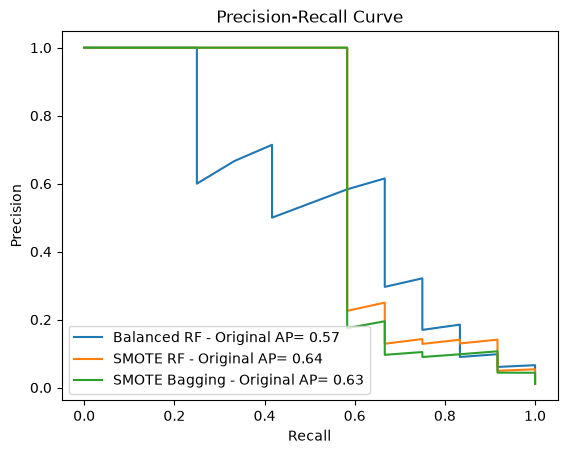

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [9]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

Balanced RF - Original - Random Forest Feature Importance


,Feature,Importance
0,Plasticizing_Position,0.100241
1,Injection_Time,0.065783
2,Max_Injection_Speed,0.063715
3,Max_Back_Pressure,0.059814
4,Max_Injection_Pressure,0.056960
5,Mold_Temperature_4,0.056770
6,Plasticizing_Time,0.053636
7,Filling_Time,0.050373
8,Mold_Temperature_3,0.049267
9,Part_RG3LH,0.049043


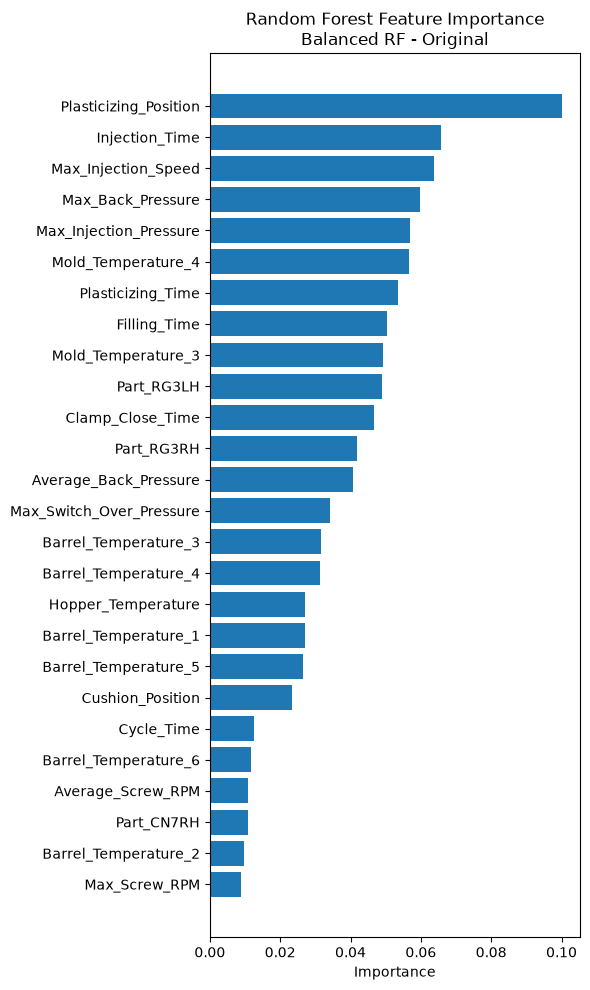

SMOTE RF - Original - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.075621
1,Max_Injection_Speed,0.070955
2,Clamp_Close_Time,0.061336
3,Max_Injection_Pressure,0.058222
4,Part_RG3RH,0.057092
5,Average_Screw_RPM,0.054769
6,Mold_Temperature_3,0.052970
7,Barrel_Temperature_5,0.049142
8,Filling_Time,0.046610
9,Mold_Temperature_4,0.043578


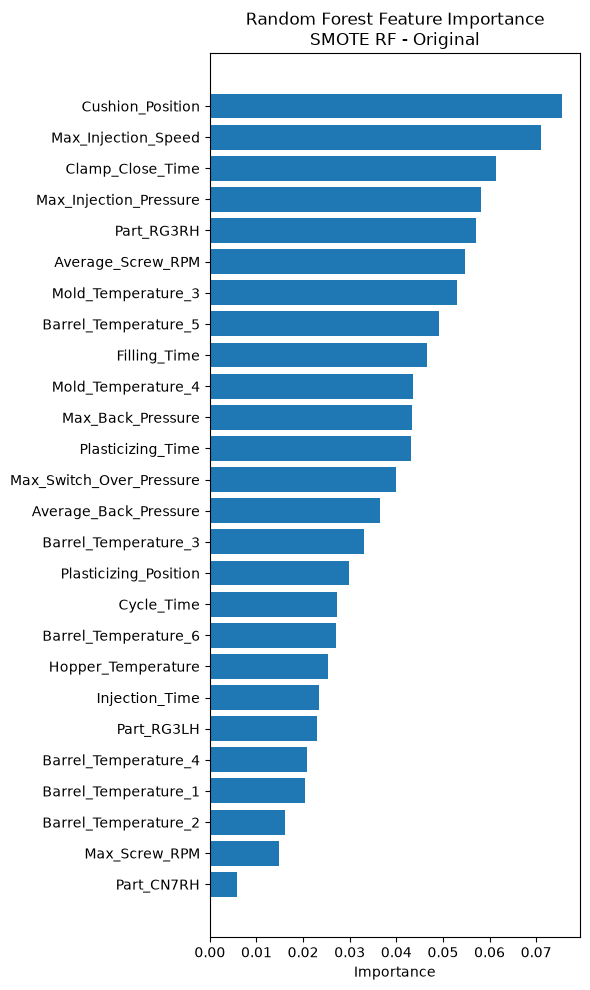

In [10]:
# model_dict에 다른 모델이 있어도 Random Forest만 표와 그래프로 출력
importance_tables = show_random_forest_feature_importance(model_dict, x_train.columns)

### 전체 PCA 95%

#### 누적 설명분산

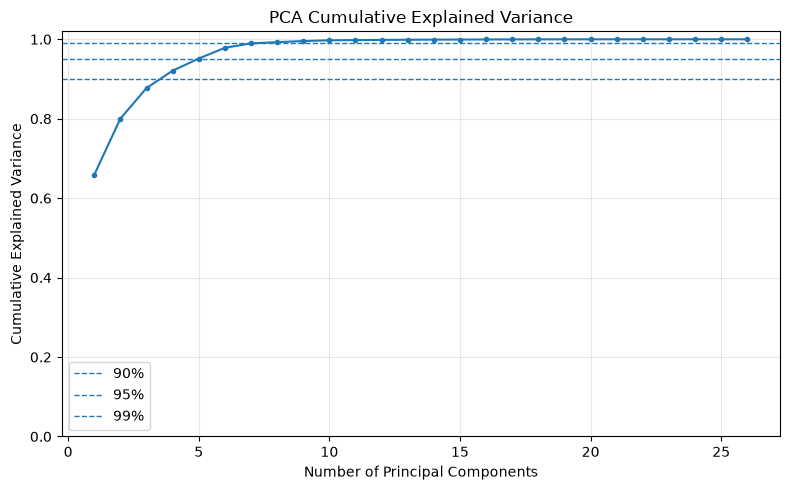

,Target Variance,Required Components
0,90%,4
1,95%,5
2,99%,8


In [11]:
# 학습 데이터에만 적합
pca_full=PCA(svd_solver='full')
pca_full.fit(x_train_scaled)

cumulative_variance=np.cumsum(pca_full.explained_variance_ratio_)
variance_targets=[0.90, 0.95, 0.99]

explained_variance_df=pd.DataFrame(
    {
        "Target Variance": [f'{int(target*100)}%' for target in variance_targets],
        "Required Components": [int(np.searchsorted(cumulative_variance, target)+1) for target in variance_targets]
    }
)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker='o', markersize=3)
for target in variance_targets:
    plt.axhline(target, linestyle='--', linewidth=1, label=f'{int(target*100)}%')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

explained_variance_df

#### 주성분 구성

In [12]:
# PC1~PC3에서 기여도(절댓값)가 큰 원본 변수
loading_df=pd.DataFrame(pca_full.components_[:3].T, index=x_train.columns, columns=['PC1', 'PC2', 'PC3'])

top_loading_rows=[]
for component in loading_df.columns:
    for feature in loading_df[component].abs().nlargest(5).index:
        top_loading_rows.append(
            {
                "Component": component,
                "Feature": feature,
                "Loading": loading_df.loc[feature, component]
            }
        )

top_loadings=pd.DataFrame(top_loading_rows)
top_loadings.round(4)

,Component,Feature,Loading
0,PC1,Injection_Time,0.2410
1,PC1,Plasticizing_Time,0.2402
2,PC1,Max_Injection_Speed,-0.2401
3,PC1,Barrel_Temperature_6,-0.2397
4,PC1,Filling_Time,0.2390
5,PC2,Max_Injection_Pressure,0.5068
6,PC2,Hopper_Temperature,-0.4577
7,PC2,Max_Back_Pressure,-0.4532
8,PC2,Barrel_Temperature_4,-0.2561
9,PC2,Clamp_Close_Time,-0.2549


#### 데이터 전처리

In [13]:
# 설명분산 95% 기준 차원 축소
pca=PCA(n_components=0.95, svd_solver='full')

x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

pca_columns=[f'PC{i}' for i in range(1, pca.n_components_+1)]
print("주성분 수:", pca.n_components_)

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_pca.shape, y_train.shape)

x_train_pca_smote, y_train_pca_smote=smote.fit_resample(x_train_pca, y_train)
print("After")
print(x_train_pca_smote.shape, y_train_pca_smote.shape)

주성분 수: 5
Before
(4184, 5) (4184,)
After
(4549, 5) (4549,)


#### 모델 학습

In [14]:
# 학습 모델 저장
model_dict={}

# Random Forest + Class Weight
rf=RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=4, class_weight='balanced', n_jobs=1, random_state=0)
rf.fit(x_train_pca, y_train)
model_dict['Balanced RF - PCA 95%']=rf

# Random Forest + SMOTE
smote_rf=RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, min_samples_leaf=4, n_jobs=1, random_state=0)
smote_rf.fit(x_train_pca_smote, y_train_pca_smote)
model_dict['SMOTE RF - PCA 95%']=smote_rf

# Bagging + SMOTE
smote_bag=BaggingClassifier(n_estimators=300, max_samples=1.0, max_features=0.5, n_jobs=1, random_state=0)
smote_bag.fit(x_train_pca_smote, y_train_pca_smote)
model_dict['SMOTE Bagging - PCA 95%']=smote_bag

#### 예측

Balanced RF - PCA 95%
Accuracy: 0.9665391969407265
Average Precision: 0.06585134738288585
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.97      0.98      1034
          불량       0.10      0.25      0.15        12

    accuracy                           0.97      1046
   macro avg       0.55      0.61      0.56      1046
weighted avg       0.98      0.97      0.97      1046



SMOTE RF - PCA 95%
Accuracy: 0.9770554493307839
Average Precision: 0.09550466320077838
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.17      0.25      0.20        12

    accuracy                           0.98      1046
   macro avg       0.58      0.62      0.59      1046
weighted avg       0.98      0.98      0.98      1046



SMOTE Bagging - PCA 95%
Accuracy: 0.9875717017208413
Average Precision: 0.033498554510951545
Classification Report
              precision    recall  f1-score   support

          양품       0.99      1.00      0.99      1034
          불량       0.00      0.00      0.00        12

    accuracy                           0.99      1046
   macro avg       0.49      0.50      0.50      1046
weighted avg       0.98      0.99      0.98      1046



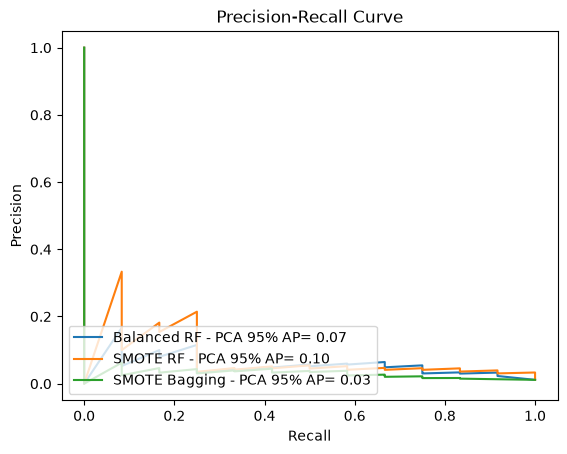

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [15]:
result_df = evaluate_models(model_dict, x_test_pca, y_test, result_df)
result_df

Balanced RF - PCA 95% - Random Forest Feature Importance


,Feature,Importance
0,PC4,0.277355
1,PC2,0.212279
2,PC3,0.211884
3,PC1,0.189221
4,PC5,0.109261


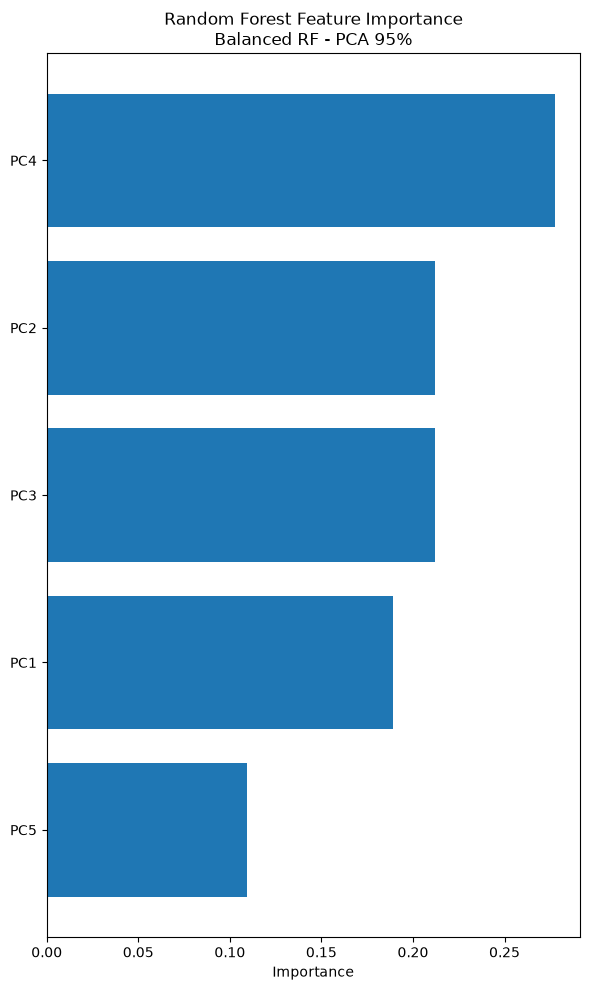

SMOTE RF - PCA 95% - Random Forest Feature Importance


,Feature,Importance
0,PC4,0.261655
1,PC3,0.215738
2,PC2,0.208333
3,PC1,0.185933
4,PC5,0.128341


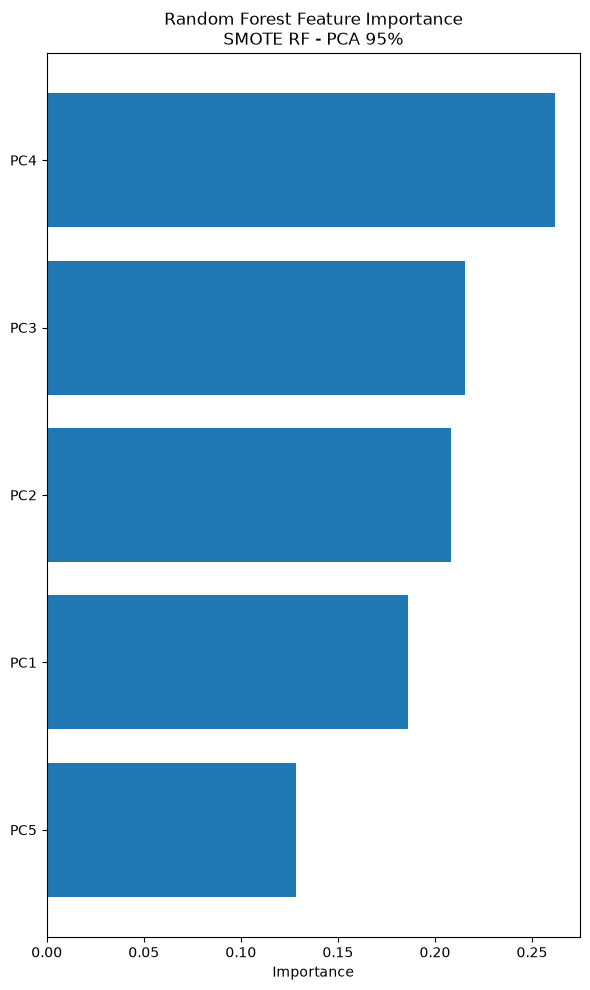

In [16]:
# 축소된 주성분 기준 중요도
importance_tables = show_random_forest_feature_importance(model_dict, pca_columns)

### 부분 PCA 95% + Part

#### 누적 설명분산

공정 변수 수: 23
보존 Part 변수: ['Part_CN7RH', 'Part_RG3LH', 'Part_RG3RH']


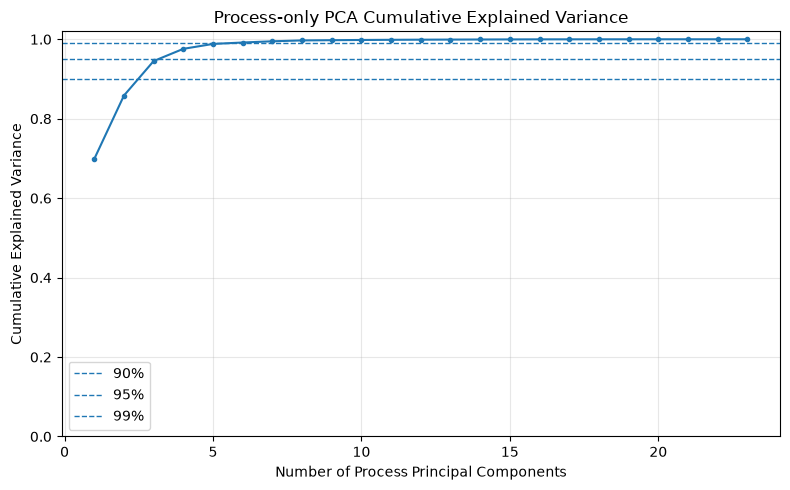

,Target Variance,Process PCA Components,Part Features Kept,Total Features
0,90%,3,3,6
1,95%,4,3,7
2,99%,6,3,9


In [17]:
# 공정 변수와 Part 더미변수 분리
process_columns=[column for column in x_train.columns if not column.startswith('Part_')]
part_columns=[column for column in x_train.columns if column.startswith('Part_')]

print("공정 변수 수:", len(process_columns))
print("보존 Part 변수:", part_columns)

# 공정 변수만 스케일링 후 누적 설명분산 확인
process_scaler=StandardScaler()
x_train_process=process_scaler.fit_transform(x_train[process_columns])
x_test_process=process_scaler.transform(x_test[process_columns])

partial_pca_full=PCA(svd_solver='full')
partial_pca_full.fit(x_train_process)

partial_cumulative_variance=np.cumsum(partial_pca_full.explained_variance_ratio_)
partial_explained_variance_df=pd.DataFrame(
    {
        "Target Variance": [f'{int(target*100)}%' for target in variance_targets],
        "Process PCA Components": [int(np.searchsorted(partial_cumulative_variance, target)+1) for target in variance_targets]
    }
)
partial_explained_variance_df['Part Features Kept']=len(part_columns)
partial_explained_variance_df['Total Features']=partial_explained_variance_df['Process PCA Components']+len(part_columns)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(partial_cumulative_variance)+1), partial_cumulative_variance, marker='o', markersize=3)
for target in variance_targets:
    plt.axhline(target, linestyle='--', linewidth=1, label=f'{int(target*100)}%')
plt.xlabel('Number of Process Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Process-only PCA Cumulative Explained Variance')
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

partial_explained_variance_df

#### 데이터 전처리

In [18]:
# 공정 변수만 설명분산 95% 기준 차원 축소
partial_pca=PCA(n_components=0.95, svd_solver='full')

x_train_process_pca=partial_pca.fit_transform(x_train_process)
x_test_process_pca=partial_pca.transform(x_test_process)

# Part 더미변수는 원형 유지
x_train_partial=np.hstack([x_train_process_pca, x_train[part_columns].to_numpy(dtype=float)])
x_test_partial=np.hstack([x_test_process_pca, x_test[part_columns].to_numpy(dtype=float)])

partial_columns=[f'PC{i}' for i in range(1, partial_pca.n_components_+1)]+part_columns
print("공정 주성분 수:", partial_pca.n_components_)
print("최종 입력 변수 수:", x_train_partial.shape[1])

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_partial.shape, y_train.shape)

x_train_partial_smote, y_train_partial_smote=smote.fit_resample(x_train_partial, y_train)
print("After")
print(x_train_partial_smote.shape, y_train_partial_smote.shape)

공정 주성분 수: 4
최종 입력 변수 수: 7
Before
(4184, 7) (4184,)
After
(4549, 7) (4549,)


#### 모델 학습

In [19]:
# 학습 모델 저장
model_dict={}

# Random Forest + Class Weight
rf=RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=4, class_weight='balanced', n_jobs=1, random_state=0)
rf.fit(x_train_partial, y_train)
model_dict['Balanced RF - Partial PCA 95% + Part']=rf

# Random Forest + SMOTE
smote_rf=RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, min_samples_leaf=4, n_jobs=1, random_state=0)
smote_rf.fit(x_train_partial_smote, y_train_partial_smote)
model_dict['SMOTE RF - Partial PCA 95% + Part']=smote_rf

# Bagging + SMOTE
smote_bag=BaggingClassifier(n_estimators=300, max_samples=1.0, max_features=0.5, n_jobs=1, random_state=0)
smote_bag.fit(x_train_partial_smote, y_train_partial_smote)
model_dict['SMOTE Bagging - Partial PCA 95% + Part']=smote_bag

#### 예측

Balanced RF - Partial PCA 95% + Part
Accuracy: 0.9550669216061185
Average Precision: 0.08723522917832008
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.96      0.98      1034
          불량       0.09      0.33      0.15        12

    accuracy                           0.96      1046
   macro avg       0.54      0.65      0.56      1046
weighted avg       0.98      0.96      0.97      1046



SMOTE RF - Partial PCA 95% + Part
Accuracy: 0.9751434034416826
Average Precision: 0.1398384917960399
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.98      0.99      1034
          불량       0.15      0.25      0.19        12

    accuracy                           0.98      1046
   macro avg       0.57      0.62      0.59      1046
weighted avg       0.98      0.98      0.98      1046



SMOTE Bagging - Partial PCA 95% + Part
Accuracy: 0.9847036328871893
Average Precision: 0.1853492327874517
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.30      0.25      0.27        12

    accuracy                           0.98      1046
   macro avg       0.65      0.62      0.63      1046
weighted avg       0.98      0.98      0.98      1046



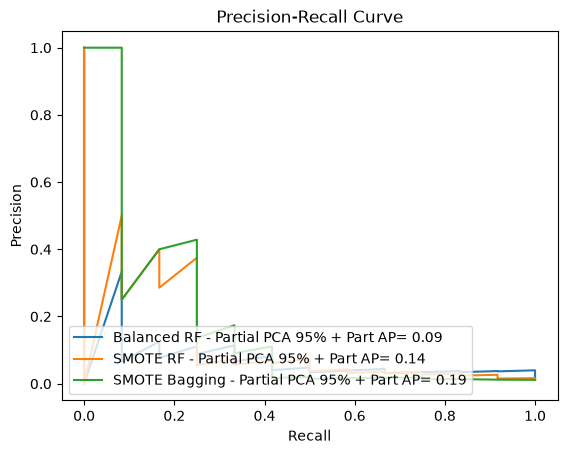

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [20]:
result_df = evaluate_models(model_dict, x_test_partial, y_test, result_df)
result_df

Balanced RF - Partial PCA 95% + Part - Random Forest Feature Importance


,Feature,Importance
0,PC2,0.249482
1,PC3,0.236790
2,PC1,0.231144
3,Part_RG3RH,0.125792
4,PC4,0.121956
5,Part_RG3LH,0.019383
6,Part_CN7RH,0.015453


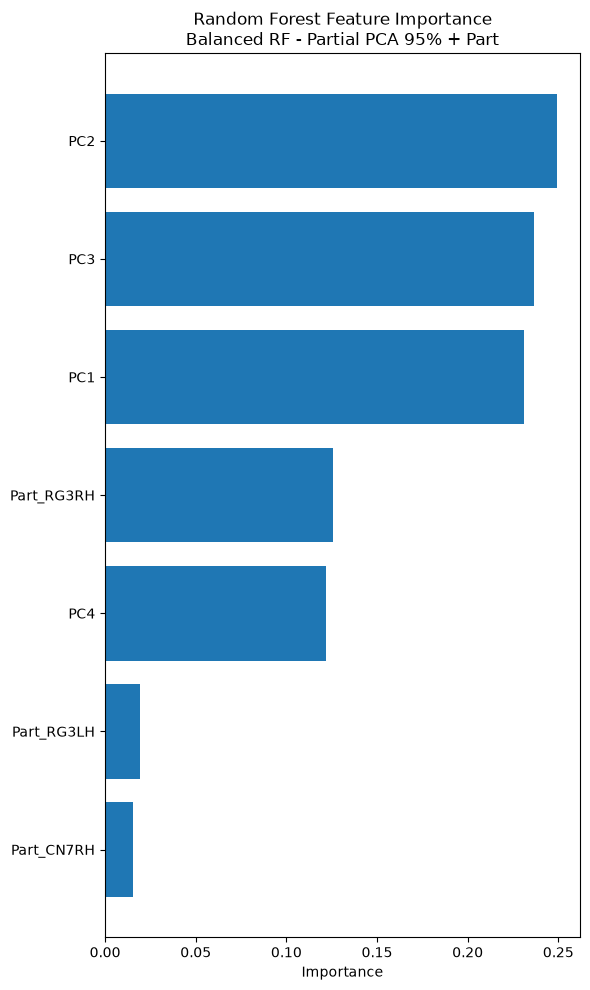

SMOTE RF - Partial PCA 95% + Part - Random Forest Feature Importance


,Feature,Importance
0,PC2,0.242378
1,PC3,0.223744
2,PC1,0.221049
3,PC4,0.159134
4,Part_RG3RH,0.096935
5,Part_CN7RH,0.041386
6,Part_RG3LH,0.015375


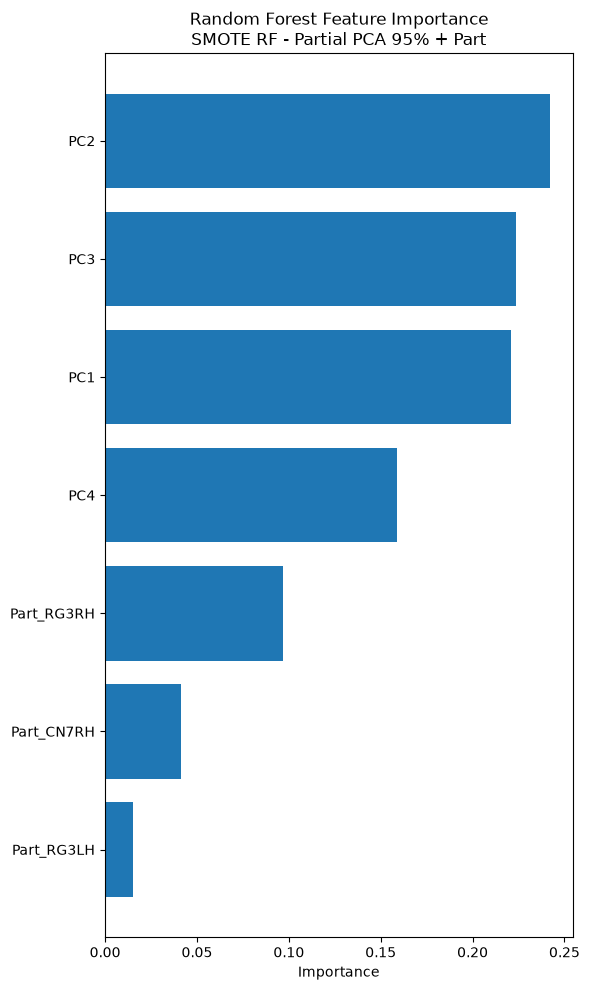

In [21]:
importance_tables = show_random_forest_feature_importance(model_dict, partial_columns)

# 모델링 결과 요약

In [22]:
pca_model_names=['Balanced RF - Original', 'Balanced RF - PCA 95%', 'Balanced RF - Partial PCA 95% + Part',
                 'SMOTE RF - Original', 'SMOTE RF - PCA 95%', 'SMOTE RF - Partial PCA 95% + Part',
                 'SMOTE Bagging - Original', 'SMOTE Bagging - PCA 95%', 'SMOTE Bagging - Partial PCA 95% + Part']

result_df[result_df['Model'].isin(pca_model_names)].sort_values(['Average Precision', 'Defect Recall', 'Defect F1 Score'], ascending=False)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
23,SMOTE RF - Original,0.777778,0.583333,0.666667,0.644045
24,SMOTE Bagging - Original,0.538462,0.583333,0.560000,0.629020
22,Balanced RF - Original,0.296296,0.666667,0.410256,0.569480
30,SMOTE Bagging - Partial PCA 95% + Part,0.300000,0.250000,0.272727,0.185349
29,SMOTE RF - Partial PCA 95% + Part,0.150000,0.250000,0.187500,0.139838
26,SMOTE RF - PCA 95%,0.166667,0.250000,0.200000,0.095505
28,Balanced RF - Partial PCA 95% + Part,0.093023,0.333333,0.145455,0.087235
25,Balanced RF - PCA 95%,0.103448,0.250000,0.146341,0.065851
27,SMOTE Bagging - PCA 95%,0.000000,0.000000,0.000000,0.033499


In [23]:
# 원본 특성 대비 변화량
compare_df=result_df[result_df['Model'].isin(pca_model_names)].drop_duplicates('Model', keep='last').set_index('Model')
metrics=['Defect Precision', 'Defect Recall', 'Defect F1 Score', 'Average Precision']

delta_rows=[]
for family in ['Balanced RF', 'SMOTE RF', 'SMOTE Bagging']:
    original=compare_df.loc[f'{family} - Original', metrics]
    for feature_set in ['PCA 95%', 'Partial PCA 95% + Part']:
        delta=compare_df.loc[f'{family} - {feature_set}', metrics]-original
        delta_rows.append({"Family": family, "Feature Set": feature_set, **{f'{metric} Delta': delta[metric] for metric in metrics}})

delta_df=pd.DataFrame(delta_rows)
delta_df.round(4)

,Family,Feature Set,Defect Precision Delta,Defect Recall Delta,Defect F1 Score Delta,Average Precision Delta
0,Balanced RF,PCA 95%,-0.1928,-0.4167,-0.2639,-0.5036
1,Balanced RF,Partial PCA 95% + Part,-0.2033,-0.3333,-0.2648,-0.4822
2,SMOTE RF,PCA 95%,-0.6111,-0.3333,-0.4667,-0.5485
3,SMOTE RF,Partial PCA 95% + Part,-0.6278,-0.3333,-0.4792,-0.5042
4,SMOTE Bagging,PCA 95%,-0.5385,-0.5833,-0.5600,-0.5955
5,SMOTE Bagging,Partial PCA 95% + Part,-0.2385,-0.3333,-0.2873,-0.4437


In [24]:
result_df.sort_values(['Defect Recall', 'Defect F1 Score', 'Average Precision'], ascending=False)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
12,RandomForest PART_NAME + Balanced,0.500000,0.666667,0.571429,0.596913
22,Balanced RF - Original,0.296296,0.666667,0.410256,0.569480
19,RandomForest PART_NAME + Balanced GridSearch,0.296296,0.666667,0.410256,0.569480
23,SMOTE RF - Original,0.777778,0.583333,0.666667,0.644045
21,Bagging PART_NAME + SMOTE St=0.1 GridSearch,0.700000,0.583333,0.636364,0.627161
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.583333,0.583333,0.583333,0.648783
13,RandomForest PART_NAME+SMOTE St=0.1,0.583333,0.583333,0.583333,0.644588
24,SMOTE Bagging - Original,0.538462,0.583333,0.560000,0.629020
14,Bagging PART_NAME+SMOTE St=0.1,0.500000,0.583333,0.538462,0.626052
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.368421,0.583333,0.451613,0.553010


In [25]:
result_df.to_csv('04_3_PCA.csv', index=False)

## 결과 요약

**차원 축소 규모**
- 전체 PCA: 원본 26개 변수 → 누적 분산 95% 지점 **주성분 5개** (90% 4개 / 99% 8개)
- 부분 PCA: 공정 변수 23개 → **주성분 4개**, Part 더미 3개 보존 → 최종 **7개 변수**
- 소수 주성분으로 분산 대부분이 설명됨 = 공정 변수 간 상관이 매우 강함

**주성분 해석 (PC1~PC3)**
- PC1: `Injection_Time` · `Plasticizing_Time` · `Filling_Time`(+) vs `Max_Injection_Speed` · `Barrel_Temperature_6`(-) → **사이클 타임 축**
- PC2: `Max_Injection_Pressure`(+0.51) vs `Hopper_Temperature` · `Max_Back_Pressure`(-0.46) → **압력·가소화 조건 축**
- PC3: `Mold_Temperature_4`(0.68) · `Mold_Temperature_3`(0.66) → **금형 온도 축**

**성능 (test 1046건 / 불량 12건)**
| 모델 | Defect Precision | Defect Recall | Defect F1 | Average Precision |
|---|---|---|---|---|
| SMOTE RF - Original | 0.778 | 0.583 | 0.667 | **0.644** |
| SMOTE Bagging - Original | 0.538 | 0.583 | 0.560 | 0.629 |
| Balanced RF - Original | 0.296 | 0.667 | 0.410 | 0.569 |
| SMOTE Bagging - Partial PCA + Part | 0.300 | 0.250 | 0.273 | 0.185 |
| SMOTE RF - Partial PCA + Part | 0.150 | 0.250 | 0.188 | 0.140 |
| SMOTE RF - PCA 95% | 0.167 | 0.250 | 0.200 | 0.096 |
| Balanced RF - Partial PCA + Part | 0.093 | 0.333 | 0.145 | 0.087 |
| Balanced RF - PCA 95% | 0.103 | 0.250 | 0.146 | 0.066 |
| SMOTE Bagging - PCA 95% | 0.000 | 0.000 | 0.000 | 0.033 |

- **PCA를 적용한 6개 조합이 모두 원본 대비 하락함** (AP -0.44 ~ -0.60, Recall -0.33 ~ -0.58)
- 전체 PCA의 `SMOTE Bagging`은 불량 **12건 중 0건 탐지**로 완전히 무너짐
- 부분 PCA(Part 더미 보존)가 전체 PCA보다는 나았지만(AP 0.185 vs 0.033), 원본 수준에는 크게 못 미침

**하락 원인**
- PCA는 **분산이 큰 방향**을 남기는데, 불량 신호는 소수 샘플의 **미세한 이탈**이라 분산 기준으로는 우선순위가 낮음 → 버려지는 하위 성분에 신호가 섞여 사라짐
- 5% 손실 분산이 양품 기준으로는 잔차지만, 불량 12건 기준으로는 **판별 정보의 상당 부분**임
- 트리 모델은 원본 변수 단위의 임계값 분할로 작동하므로, 변수가 선형 결합되면 **분할 기준 자체가 흐려짐** (상관 제거의 이득보다 손실이 큼)
- Part 더미를 보존했을 때 회복 폭이 있었던 것은 **제품 구분 정보가 불량 판별에 직접 기여**한다는 04_1 결과와 일치함

**결론**
- **PCA 미채택.** 원본 변수 체계를 유지하고, 차원 축소가 아닌 **변수 선택** 방향으로 진행 (→ 04_4)
- 다변량 압축이 필요한 경우 선형 PCA가 아닌 **비선형 재구성 오차 기반 접근**을 검토 (→ 04_5 AutoEncoder)
- 위 수치는 단일 분할(`random_state=0`) 기준 **후보 비교용**이며, 확정 수치는 04_6 반복 CV 결과를 따름
